In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
df=pd.read_csv(r"C:\Users\ASUS\OneDrive\Documents\employee_data_analysis.csv")
df

,Employee_ID,Name,Age,Gender,Department,City,Experience_Years,Salary,Performance_Score,Projects_Completed,Working_Hours_Per_Week,Job_Satisfaction
0,1001,Karan,28,Female,Finance,Aurangabad,10.9,59529,7.7,5,36.0,4.0
1,1002,Meera,29,Male,Sales,Aurangabad,9.2,100703,1.3,15,32.0,5.0
2,1003,Pooja,25,Male,Marketing,Nagpur,6.3,101090,6.1,13,32.0,1.0
3,1004,Neha,21,Female,HR,Nashik,14.0,42260,7.9,8,47.0,1.0
4,1005,Harsh,39,Female,Sales,Pune,13.0,28812,8.9,1,34.0,3.0
5,1006,Rahul,31,Male,IT,Mumbai,7.5,75000,8.2,10,40.0,4.0
6,1007,Priya,27,Female,Finance,Pune,5.8,68000,7.5,6,38.0,4.0
7,1008,Aditya,35,Male,Marketing,Nagpur,8.4,82000,6.8,9,42.0,3.0
8,1009,Anjali,30,Female,HR,Nashik,6.2,54000,8.5,7,37.0,5.0
9,1010,Rohit,40,Male,Sales,Mumbai,12.5,95000,7.1,12,45.0,3.0


In [67]:
df.size

144

In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Employee_ID             12 non-null     int64  
 1   Name                    12 non-null     str    
 2   Age                     12 non-null     int64  
 3   Gender                  12 non-null     str    
 4   Department              12 non-null     str    
 5   City                    12 non-null     str    
 6   Experience_Years        12 non-null     float64
 7   Salary                  12 non-null     int64  
 8   Performance_Score       12 non-null     float64
 9   Projects_Completed      12 non-null     int64  
 10  Working_Hours_Per_Week  11 non-null     float64
 11  Job_Satisfaction        11 non-null     float64
dtypes: float64(4), int64(4), str(4)
memory usage: 1.3 KB


In [69]:
df.describe()

,Employee_ID,Age,Experience_Years,Salary,Performance_Score,Projects_Completed,Working_Hours_Per_Week,Job_Satisfaction
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,11.000000,11.000000
mean,1006.500000,32.166667,8.966667,70328.416667,6.650000,7.583333,37.636364,3.818182
std,3.605551,6.846809,3.516282,25298.938334,2.126243,4.561864,5.390227,2.182576
min,1001.000000,21.000000,2.300000,28812.000000,1.300000,0.000000,31.000000,1.000000
25%,1003.750000,27.750000,6.275000,51065.000000,5.875000,5.000000,33.000000,3.000000
50%,1006.500000,30.500000,8.800000,71500.000000,7.300000,7.500000,37.000000,4.000000
75%,1009.250000,37.500000,11.750000,95289.500000,7.975000,10.500000,41.000000,4.500000
max,1012.000000,44.000000,14.000000,101090.000000,8.900000,15.000000,47.000000,9.000000


In [70]:
df.head()

,Employee_ID,Name,Age,Gender,Department,City,Experience_Years,Salary,Performance_Score,Projects_Completed,Working_Hours_Per_Week,Job_Satisfaction
0,1001,Karan,28,Female,Finance,Aurangabad,10.9,59529,7.7,5,36.0,4.0
1,1002,Meera,29,Male,Sales,Aurangabad,9.2,100703,1.3,15,32.0,5.0
2,1003,Pooja,25,Male,Marketing,Nagpur,6.3,101090,6.1,13,32.0,1.0
3,1004,Neha,21,Female,HR,Nashik,14.0,42260,7.9,8,47.0,1.0
4,1005,Harsh,39,Female,Sales,Pune,13.0,28812,8.9,1,34.0,3.0


In [71]:
df.isnull().sum()

Employee_ID               0
Name                      0
Age                       0
Gender                    0
Department                0
City                      0
Experience_Years          0
Salary                    0
Performance_Score         0
Projects_Completed        0
Working_Hours_Per_Week    1
Job_Satisfaction          1
dtype: int64

In [72]:
df.duplicated().sum()

np.int64(0)

In [73]:
med_age=df['Age'].median()()
med_age

TypeError: 'numpy.float64' object is not callable

In [74]:
med_sal=df['Salary'].median()
med_sal


np.float64(71500.0)

In [75]:
df['Salary']=df['Salary'].fillna(med_sal)

In [76]:
df['City']=df['City'].fillna('Unknown')

In [77]:
med_pscore=df['Performance_Score'].median()
med_pscore

np.float64(7.3)

In [78]:
df['Performance_Score']=df['Performance_Score'].fillna(med_pscore)

In [79]:
df.isnull().sum()

Employee_ID               0
Name                      0
Age                       0
Gender                    0
Department                0
City                      0
Experience_Years          0
Salary                    0
Performance_Score         0
Projects_Completed        0
Working_Hours_Per_Week    1
Job_Satisfaction          1
dtype: int64

In [80]:
df.groupby('Department')['Salary'].mean()

Department
Finance      63764.500000
HR           64139.333333
IT           75000.000000
Marketing    74826.333333
Sales        74838.333333
Name: Salary, dtype: float64

In [81]:
num_cols = [
    'Age', 
    'Experience_Years', 
    'Salary', 
    'Performance_Score', 
    'Projects_Completed', 
    'Working_Hours_Per_Week'
]

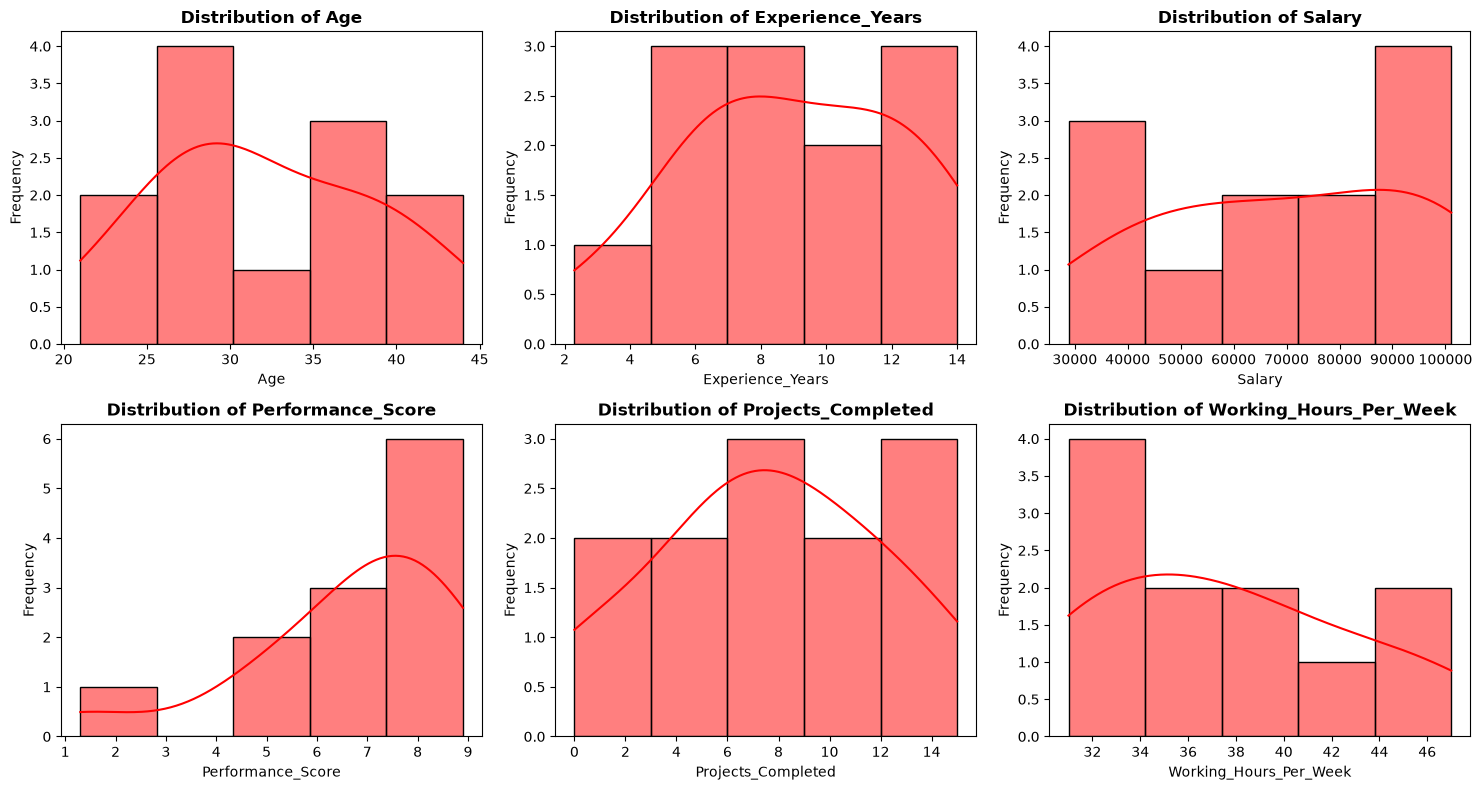

In [82]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='red', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [83]:
df_cleaned=df

In [84]:

df_cleaned.to_csv('cleaned_employee_data.csv', index=False)


In [88]:
## Using forward slashes (recommended for clean syntax)
df_cleaned.to_csv(r"C:\Users\ASUS\OneDrive\Documents\employee_data_analysis.csv", index=False)